In [ ]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
from metpy.units import units
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, Polygon
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
from collections import OrderedDict
import sys
import matplotlib.colors as colors

# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Input data
# EURO-CORDEX RCMs
RCMs = OrderedDict() 
RCMs['CNRM-ALADIN64E1'] = {'projplot' : 'LambertConformal',
                           'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['HCLIM43-ALADIN'] = {'projplot' : 'LambertConformal',
                          'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['ALARO1-SFX'] = {'projplot' : 'LambertConformal',
                      'projplot_dict' : dict(central_longitude=9.9, central_latitude=49.0, standard_parallels=(33,45), false_easting = 3012.5, false_northing = 3012.5)}
RCMs['RACMO23E']   = {'projplot' : 'RotatedPole',
                      'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['ICON-CLM-202407-1-1'] = {'projplot' : 'RotatedPole',
                               'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['CCLM6-0-1'] = {'projplot' : 'RotatedPole',
                     'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['RegCM5-0'] = {'projplot' : 'RotatedPole',
                    'projplot_dict' : dict(pole_longitude=198, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['REMO2020-2-2'] = {'projplot' : 'RotatedPole',
                        'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['WRF451Q'] = {'projplot' : 'RotatedPole',
                   'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_CNRM-ALADIN64E1','ERA5_ALARO1-SFX','ERA5_CCLM6-0-1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALADIN64E1','ALARO1-SFX','CCLM6-0-1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']
name_obs = 'OBS_EURADCLIM_011EUi_2013-2022'

gdf = gpd.read_file("regions.geojson")

def quatromatrix(left, bottom, right, top, ax=None, triplotkw={},tripcolorkw={}):
    if not ax: ax=plt.gca()
    n = left.shape[0]; m=left.shape[1]

    a = np.array([[0,0],[0,1],[.5,.5],[1,0],[1,1]])
    tr = np.array([[0,1,2], [0,2,3],[2,3,4],[1,2,4]])

    A = np.zeros((n*m*5,2))
    Tr = np.zeros((n*m*4,3))

    for i in range(n):
        for j in range(m):
            k = i*m+j
            A[k*5:(k+1)*5,:] = np.c_[a[:,0]+j, a[:,1]+i]
            Tr[k*4:(k+1)*4,:] = tr + k*5

    C = np.c_[ left.flatten(), bottom.flatten(), 
              right.flatten(), top.flatten()   ].flatten()

    triplot = ax.triplot(A[:,0], A[:,1], Tr, **triplotkw)
    tripcolor = ax.tripcolor(A[:,0], A[:,1], Tr, facecolors=C, **tripcolorkw)
    return tripcolor

In [47]:
# at an hourly scale
agg = '1'

# quantile
quantile = 'perc_99.90'

# initialise list
dict_median = {}

vecregion = ["France","Mid-Europe","Mediterranean"]
    
# 2. Run the loop to collect small dataframes
for iseason, season in enumerate(['JJA','SON','DJF','MAM']):
    print("=============================================================")
    print(season)        
    print("=============================================================")

    # initiliase dict for each season
    dict_median[season] = np.zeros((len(vecregion),len(name_models)))
    
    for iregion, region in enumerate(vecregion):
        if region == "France":
            name_obs = "OBS_COMEPHORE_011EUi_1997-2022"
        elif region == "Mid-Europe":
            name_obs = "OBS_RADKLIM_011EUi_2001-2022"
        elif region == "Mediterranean":
            name_obs = "OBS_GRIPHO_011EUi_2001-2016"

        gdfregion = gdf.loc[gdf['names'] == region]
        minx, miny, maxx, maxy = gdfregion.geometry.total_bounds
                    
        fObs = f'{name_obs}_{season}_all_{agg}h_perc.nc'
        dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
        dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])
        
        for imodel, model in enumerate(name_models):
            # corresponding label for the model
            model_label = label_models[name_models.index(model)]
            
            # reference file for the regridding
            fMod = f'{model}1980-2020_{season}_all_{agg}h_perc.nc'
            print(fMod)
            
            # aladin simulation to be regridded
            dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

            if model == 'ERA5_RegCM5-0':
                dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

            dsMod = dsMod.cf.add_bounds(["lon","lat"])

            # regrid obs
            regridder = xe.Regridder(
                dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
            )
            dsMod_regrid = regridder(dsMod, keep_attrs=True)

            ZOBS = dsObs_cor[quantile]
            ZMOD = dsMod_regrid[quantile]

            Z = (ZMOD / ZOBS - 1) * 100

            Z2CLIP = dsObs_cor[quantile].copy(deep=True)
            Z2CLIP.values = Z
            Z2CLIP.rio.write_crs("EPSG:4326", inplace=True)
            
            # prepare data for the plot
            Zclip = Z2CLIP.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
            zvec = Zclip.values.flatten()
            zvec = zvec[~np.isnan(zvec)]

            dict_median[season][iregion,imodel] = np.median(zvec)


JJA
ERA5_CNRM-ALADIN64E11980-2020_JJA_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ERA5_ALARO1-SFX1980-2020_JJA_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


ERA5_CCLM6-0-11980-2020_JJA_all_1h_perc.nc


...

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


ERA5_REMO2020-2-21980-2020_MAM_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ERA5_WRF451Q1980-2020_MAM_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


In [50]:
for season in ["JJA","MAM","SON","DJF"]:
    filecsv = f'D:/EUROCORDEX_extremes/FIGURES/BIAS_HOURLY_NATIONALPRODUCTS/heatmap_{agg}h_reldiff_{quantile}_{season}.csv'
    np.savetxt(filecsv, dict_median[season],delimiter=',', fmt='%f')


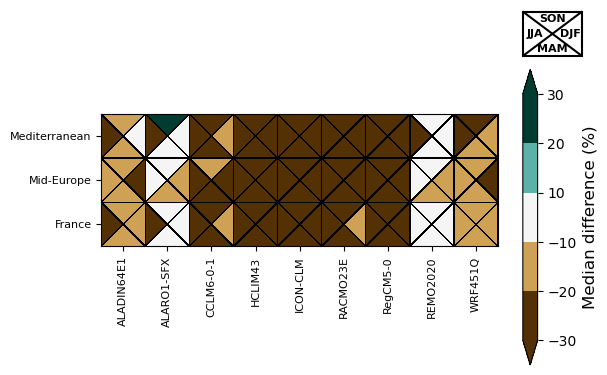

In [48]:
#======================================================================
# STEP 5: FIGURE HEATMAP MEDIAN, OTHER COLOR SCALE
#======================================================================

# format df_median to be used in the quatromatrix function
vecregion = vecregion
vecmodel = label_models

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-20,-10,10,20,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, ax=plt.subplots()

p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

ax.margins(0)
ax.set_aspect("equal")

# change the ticks and labels
ax.set_xticks(np.arange(len(vecmodel))+0.5)
ax.set_xticklabels(vecmodel, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(vecregion))+0.5)
ax.set_yticklabels(vecregion, fontsize=8)

# add colorbar
cbar = fig.colorbar(p, ax=ax, aspect=20, orientation="vertical", shrink=0.8, 
                    anchor=(0.0, 0.0),  extend='both', extendfrac=0.1)
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

# save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/BIAS_HOURLY_NATIONALPRODUCTS/heatmap_{agg}h_reldiff_{quantile}_discretecolors.png', 
            dpi=300, bbox_inches='tight')